# 1. Implementación

In [459]:
%pip install tensorboard
%pip install requests

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [460]:
# Instala/actualiza librerías necesarias para este cuaderno
%pip install -q numpy matplotlib scikit-learn pillow 
%pip install -q seaborn
%pip install -q tensorflow keras


import importlib

modules_to_check = [
    ("numpy", "np"),
    ("matplotlib", "plt"),
    ("sklearn", "sklearn"),
    ("tensorflow", "tf"),
    ("seaborn", "sns"),
]

for module_name, alias in modules_to_check:
    try:
        importlib.import_module(module_name)
        print(f"{module_name} OK")
    except ImportError:
        print(f"{module_name} NOT INSTALLED")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
numpy OK
matplotlib OK
sklearn OK
tensorflow OK
seaborn OK


## 1.1 Separar los datos manualmente

In [461]:
import os 

import shutil 

import random 

if not os.path.exists('data_split'): 

    original_dir = 'data' # tu carpeta actual con clases 
    base_dir = 'data_split' 
    train_dir = os.path.join(base_dir, 'train') 
    val_dir = os.path.join(base_dir, 'val') 
    test_dir = os.path.join(base_dir, 'test') 

    for folder in [train_dir, val_dir, test_dir]: 
        os.makedirs(folder, exist_ok=True) 

 

    # recorrer clases 

    for class_name in os.listdir(original_dir): 
        class_path = os.path.join(original_dir, class_name)  
        if not os.path.isdir(class_path): 
            continue 
        images = os.listdir(class_path) 
        random.shuffle(images)  
        n_total = len(images) 
        n_train = int(0.7 * n_total) 
        n_val = int(0.15 * n_total) 
        train_images = images[:n_train] 
        val_images = images[n_train:n_train + n_val] 
        test_images = images[n_train + n_val:] 
        # crear subcarpetas 
        for split, split_images in zip( 
            ['train', 'val', 'test'], 
            [train_images, val_images, test_images] 
        ): 
            split_class_dir = os.path.join(base_dir, split, class_name) 
            os.makedirs(split_class_dir, exist_ok=True) 
            for img in split_images: 
                src = os.path.join(class_path, img) 
                dst = os.path.join(split_class_dir, img) 
                shutil.copyfile(src, dst) 

In [462]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Generador con data augmentation para entrenamiento
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,        
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,           
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    validation_split=0.2
)

# Generador para validación y evaluación, sin augmentation
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)
test_val_datagen= ImageDataGenerator(
    rescale=1./255
)

In [463]:
data_dir = "./Data"

train_generator = train_datagen.flow_from_directory(
    'data_split/train',
    target_size=(96, 96),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    'data_split/val',
    target_size=(96, 96),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test_generator = test_val_datagen.flow_from_directory(
    'data_split/test',
    target_size=(96, 96),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 33096 images belonging to 5 classes.
Found 1770 images belonging to 5 classes.
Found 8870 images belonging to 5 classes.


## Visión de los imágenes

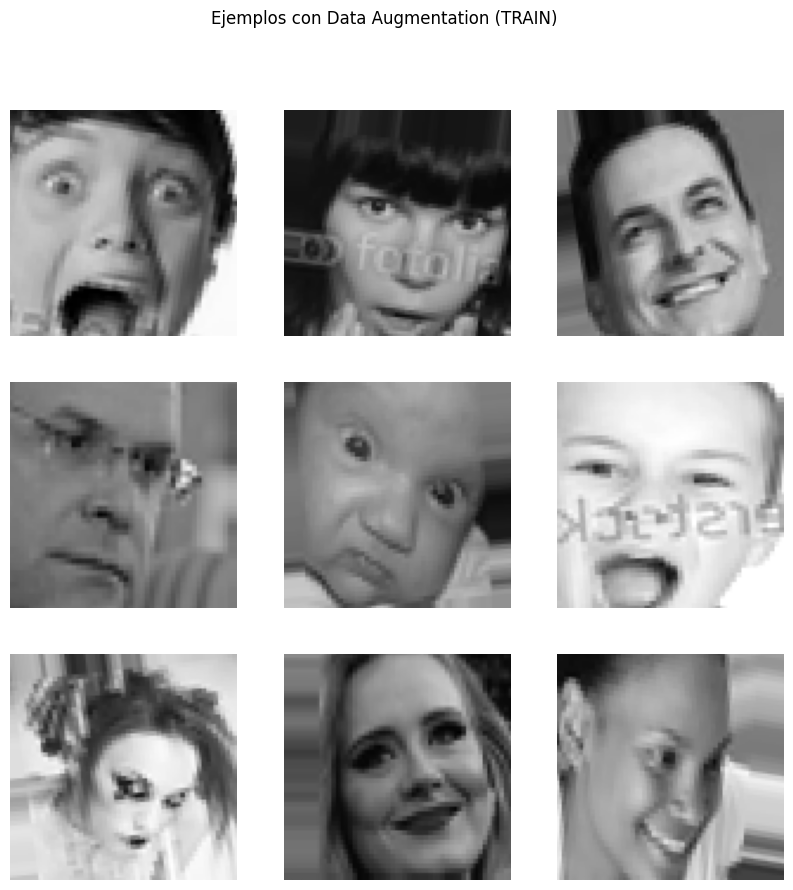

In [464]:
import matplotlib.pyplot as plt

# Obtener un batch
images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis('off')

plt.suptitle("Ejemplos con Data Augmentation (TRAIN)")
plt.show()

# 2.0 Entrenamiento

## 2.1 Establecer los parámetros de entrenamiento

In [465]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_generator.classes)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_generator.classes
)

class_weight = dict(zip(classes, class_weights_array))

Peso aumentado en clase 1 para que el modelo lo pueda entrenar mejor

In [466]:
class_weight = {
    0: 1.0,
    1: 2.0,
    2: 0.8,   
    3: 1.2,
    4: 1.0
}

Establecemos parámetros

In [467]:
input_size = 96
num_colors = 3

learning_rate = 1.e-4
# learning_rate = [0.01, 0.001, 0.0001]
epochs = 30
batch_size = 32
# bath_size = [16, 32, 64]
kernel_sizes = 3
#filters = [32, 64, 128]

## 2.2 Construcción de la estructura de la red

In [468]:
from tensorflow import keras
from tensorflow.keras import layers

def build_model():
    inputs = keras.Input(shape=(96, 96, 3))

    # BLOQUE 1
    x = layers.Conv2D(32, (3,3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(32, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.2)(x)

    # BLOQUE 2
    x = layers.Conv2D(64, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(64, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    # BLOQUE 3
    x = layers.Conv2D(128, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(128, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.4)(x)

    # BLOQUE 4 (más profundo)
    x = layers.Conv2D(256, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(256, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.4)(x)

    # HEAD
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(5, activation='softmax')(x)

    model = keras.Model(inputs, outputs)

    return model

## 2.3 Monitoreo para ver el progreso del modelo por cada época

In [469]:
import datetime
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ReduceLROnPlateau
log_dir = "logs/train/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

tensorboard_callback = TensorBoard(log_dir=log_dir)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5, #CAMBIADO
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3, #CAMBIADO
    patience=3,
    min_lr=1e-6,
    verbose=1
)

## 2.4 Funciones para calcular accuracy, precision, recall, f1-score y amtriz de confusión para enviarlas a telegram

In [470]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluar_modelo(history, y_true, y_pred):

    acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    loss = history.history['loss'][-1]
    val_loss = history.history['val_loss'][-1]

    print(f"Accuracy final: {acc:.3f}")
    print(f"Validation Accuracy: {val_acc:.3f}")

    # 1. Detectar overfitting
    if acc - val_acc > 0.1:
        print("Posible OVERFITTING")
        
        plt.plot(history.history['accuracy'])
        plt.plot(history.history['val_accuracy'])
        plt.legend(['train', 'val'])
        plt.title('Overfitting Detection')
        plt.show()

    else:
        print("No hay overfitting claro")

    # 2. Detectar underfitting
    if acc < 0.5:
        print("Posible UNDERFITTING")

    # 3. Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Matriz de confusión")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()

    # 4. Classification report
    report = classification_report(y_true, y_pred, output_dict=True)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    # 5. Detectar clases problemáticas
    for clase, datos in report.items():
        if clase.isdigit():
            recall = datos['recall']
            if recall < 0.6:
                print(f"Clase {clase} con bajo recall ({recall:.2f})")

                # Mostrar gráfico de esa clase
                plt.bar(['precision', 'recall', 'f1'],
                        [datos['precision'], datos['recall'], datos['f1-score']])
                plt.title(f"Clase problemática: {clase}")
                plt.show()

In [471]:
import requests

TOKEN = "8536752415:AAGnygXDRfAQEOO6yDg78Ia3d_XuhzK9MHg"
CHAT_ID = "8788334375"

def send(msg):
    url = f"https://api.telegram.org/bot{TOKEN}/sendMessage"
    requests.post(url, data={"chat_id": CHAT_ID, "text": msg})

In [472]:
def evaluar_y_notificar(history, y_true, y_pred):

    acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]

    mensaje = f"""
  RESULTADOS DEL MODELO

Accuracy: {acc:.3f}
Val Accuracy: {val_acc:.3f}
"""

    # detectar overfitting
    if acc - val_acc > 0.1:
        mensaje += "\n Overfitting detectado"

    # classification report
    from sklearn.metrics import classification_report
    report = classification_report(y_true, y_pred)

    mensaje += "\n\n Classification Report:\n"
    mensaje += report

    send(mensaje)

In [473]:
def send_image(path):
    url = f"https://api.telegram.org/bot{TOKEN}/sendPhoto"
    with open(path, "rb") as img:
        requests.post(url, files={"photo": img}, data={"chat_id": CHAT_ID})

## 2.5 Proceso de entrenamiento

In [474]:
import tensorflow as tf
print("GPUs disponibles:", tf.config.list_physical_devices('GPU'))
print("Dispositivos:", tf.config.list_physical_devices())
print(tf.__version__)
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.optimizers import Adam

print(f"\nProbando kernel={3,3}")

model = build_model()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1), #loss='categorical_crossentropy',
    # loss = tf.keras.losses.CategoricalFocalCrossentropy(), # # cambio
    metrics=['accuracy',  
        Precision(name='precision'),
        Recall(name='recall')]
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[tensorboard_callback, early_stop, reduce_lr],
    class_weight=class_weight
)
val_acc = max(history.history['val_accuracy'])
test_generator.reset()

y_pred = model.predict(test_generator)
y_pred = np.argmax(y_pred, axis=1)
y_true = test_generator.classes



GPUs disponibles: []
Dispositivos: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
2.21.0

Probando kernel=(3, 3)
Epoch 1/30
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 1043s 996ms/step - accuracy: 0.2188 - loss: 2.4723 - precision: 0.2215 - recall: 0.1046 - val_accuracy: 0.2797 - val_loss: 1.6362 - val_precision: 0.1605 - val_recall: 0.0073 - learning_rate: 1.0000e-04
Epoch 2/30
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 834s 805ms/step - accuracy: 0.2248 - loss: 2.1726 - precision: 0.2336 - recall: 0.0717 - val_accuracy: 0.2938 - val_loss: 1.6197 - val_precision: 0.6667 - val_recall: 0.0023 - learning_rate: 1.0000e-04
Epoch 3/30
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 830s 801ms/step - accuracy: 0.2297 - loss: 2.0440 - precision: 0.2358 - recall: 0.0508 - val_accuracy: 0.3260 - val_loss: 1.6194 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 4/30
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 830s 802ms/step - accuracy: 0.2392 - loss: 1.9651 - precision: 0.2494 - recall: 0.03

# 3. Evaluación

Accuracy final: 0.648
Validation Accuracy: 0.695
No hay overfitting claro


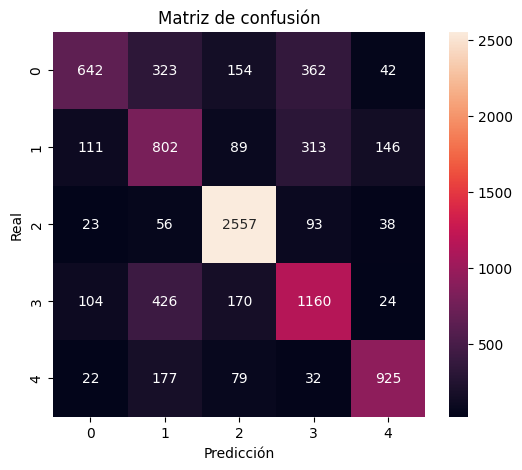


Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.42      0.53      1523
           1       0.45      0.55      0.49      1461
           2       0.84      0.92      0.88      2767
           3       0.59      0.62      0.60      1884
           4       0.79      0.75      0.77      1235

    accuracy                           0.69      8870
   macro avg       0.68      0.65      0.65      8870
weighted avg       0.69      0.69      0.68      8870

Clase 0 con bajo recall (0.42)


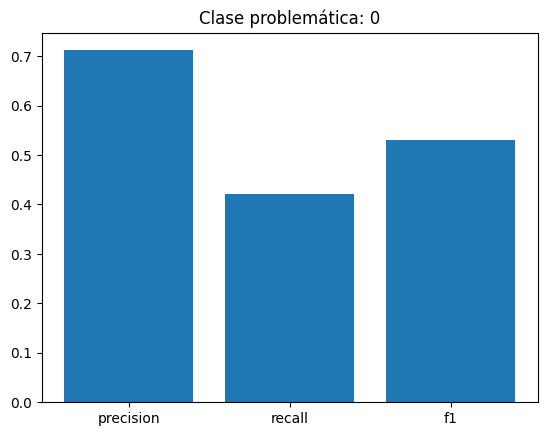

Clase 1 con bajo recall (0.55)


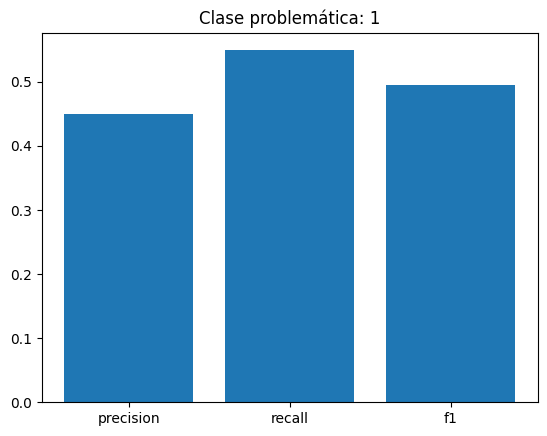

In [475]:
send("✔ Tu ejecución en WSL ha terminado")
evaluar_modelo(history, y_true, y_pred)
evaluar_y_notificar(history, y_true, y_pred)

## 3.1 Accuracy vs Validation

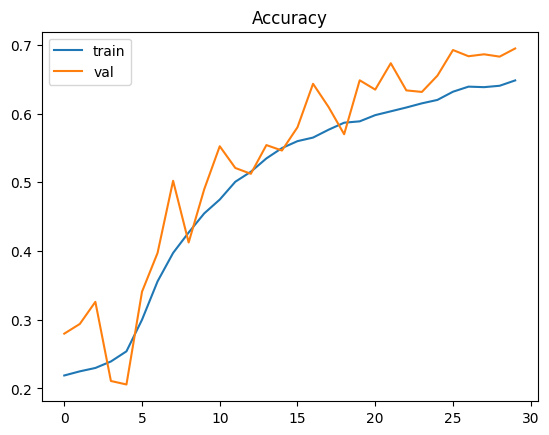

In [476]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train', 'val'])
plt.title('Accuracy')
plt.show()

## 3.2 Loss vs Accuracy

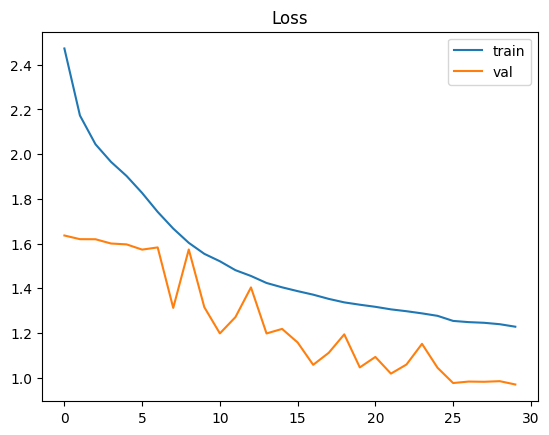

In [477]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train', 'val'])
plt.title('Loss')
plt.show()

In [478]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.42      0.53      1523
           1       0.45      0.55      0.49      1461
           2       0.84      0.92      0.88      2767
           3       0.59      0.62      0.60      1884
           4       0.79      0.75      0.77      1235

    accuracy                           0.69      8870
   macro avg       0.68      0.65      0.65      8870
weighted avg       0.69      0.69      0.68      8870



## 3.3 Muestra de matriz de confusión


Evaluando kernel=(3, 3)
278/278 ━━━━━━━━━━━━━━━━━━━━ 65s 232ms/step


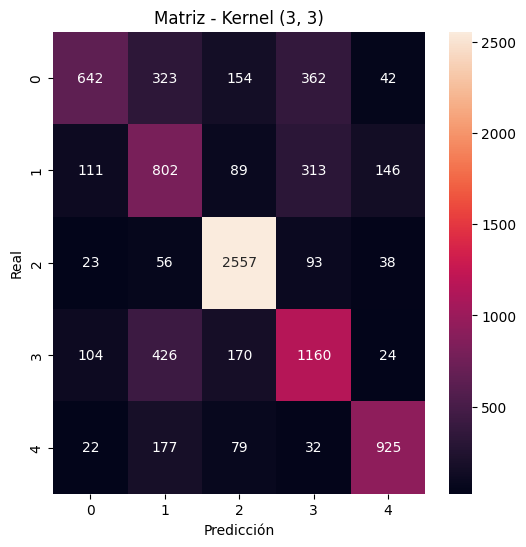

In [479]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print(f"\nEvaluando kernel={3,3}")

test_generator.reset()
preds = model.predict(test_generator)

y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title(f"Matriz - Kernel {3,3}")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

## 3.4 Verficación del mejor accuracy que el modelo ha podido llegar

In [480]:
print(f"Kernel {3,3} → Val Accuracy: {val_acc:.4f}")

Kernel (3, 3) → Val Accuracy: 0.6949


Puede que haya una posible desbalance en el dataset, y esto explicaría porque hay uno de las clases que está rindiendo tan poco.

In [481]:
import numpy as np

unique, counts = np.unique(train_generator.classes, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Clase {u}: {c} muestras")

Clase 0: 5683 muestras
Clase 1: 5450 muestras
Clase 2: 10326 muestras
Clase 3: 7030 muestras
Clase 4: 4607 muestras


In [482]:
print(class_weight)

{0: 1.0, 1: 2.0, 2: 0.8, 3: 1.2, 4: 1.0}


In [483]:
print(preds.sum(axis=1))  # should be ~1 for each sample if softmax
x, y = next(val_generator)
print(y[:3])
tf.keras.layers.Dense(5, activation='softmax')

[1.         1.         0.99999994 ... 0.99999994 0.99999994 0.99999994]
[[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]]


<Dense name=dense_51, built=False>

No hay desbalanceo

## 3.4 Resultados del modelo pasándolo a telegram

In [484]:
#Se almacena la imagen de la matriz de la confusión
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")

plt.savefig("confusion_matrix.png")
plt.close()

# 4.0 Prueba del modelo con nuevas imágenes

In [485]:
%pip install torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.


In [486]:
model.save("model.keras")

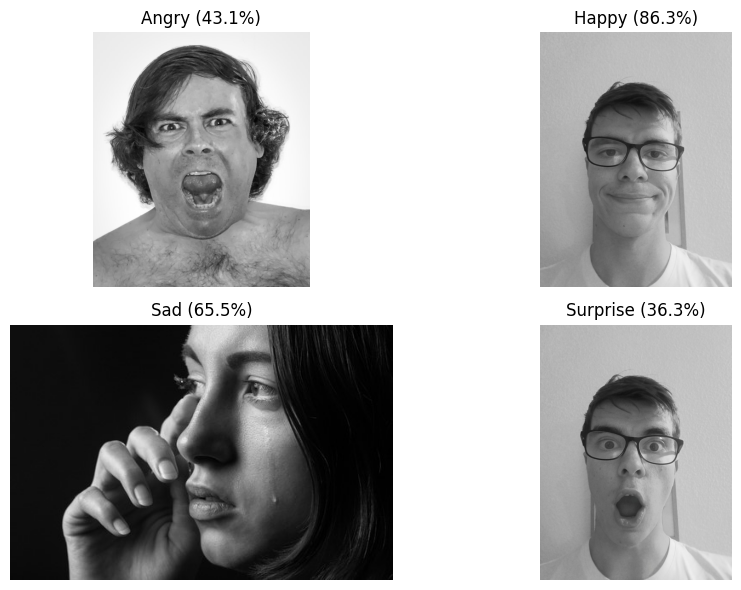

In [488]:
from tensorflow.keras.models import load_model 

from tensorflow.keras.preprocessing import image 

import numpy as np 

import matplotlib.pyplot as plt 

# cargar modelo 

model = load_model("model.keras") 

# Número de clases 

class_names = ["Angry","Fear", "Happy", "Sad", "Surprise"] 

imgs = ["New_images/Fear.jpg", "New_images/Santi_happy.jpg", "New_images/Sad.jpg", "New_images/Santi_surprise.jpg"] 

plt.figure(figsize=(10, 6)) 

for i, img_path in enumerate(imgs): 

    # cargar imagen 
    img = image.load_img(img_path, target_size=(96, 96)) 
    x = image.img_to_array(img) / 255.0 
    x = np.expand_dims(x, axis=0) 

    # predicción 
    preds = model.predict(x, verbose=0)[0] 
    class_idx = np.argmax(preds) 
    confidence = preds[class_idx] * 100 

    # mostrar imagen 
    plt.subplot(2, 2, i+1) 
    plt.imshow(image.load_img(img_path))
    plt.title(f"{class_names[class_idx]} ({confidence:.1f}%)")  
    plt.axis("off")
 

# GUARDAR IMAGEN
output_path = "predicciones.png"
plt.tight_layout()
plt.savefig(output_path)
plt.show()
plt.close()

# ENVIAR POR TELEGRAM
send_image(output_path)
 